In [33]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import hist

In [43]:
with open('inputs/rho/rho_data_all.pkl', 'rb') as f:
    data = pkl.load(f)
with open('inputs/rho/jms_pythiaV2_all_syst.pkl', 'rb') as f:
    pythia = pkl.load(f)

with open('inputs/rho/sys_matrix_dic_rho_ungroomed_v2.pkl', 'rb') as f:
    pythia2 = pkl.load(f)

In [44]:
hdata = data['ptjet_rhojet_g_reco'].project('ptreco')
hpythia = pythia['ptjet_rhojet_g_reco'][{'systematic': 'nominal'}].project('ptreco')

In [45]:
for i in range(4):
    hpythia.view()[i] *= ratio[i]

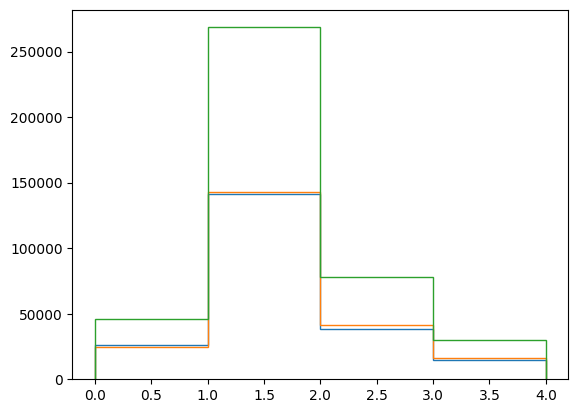

In [51]:
plt.stairs(pythia2['nominal'].sum(axis = (0,1,3)))
plt.stairs(hpythia.project('ptreco').values())
plt.stairs(hdata.project('ptreco').values())

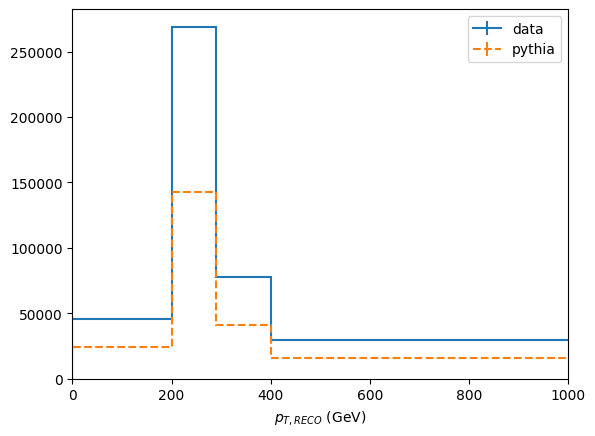

In [41]:
density = False

hdata.project('ptreco').plot(label = 'data', density = density)
hpythia.project('ptreco').plot(label = 'pythia', density = density, ls = '--', alpha = 1)
plt.xlim(0, 1000)
plt.legend()

In [14]:
print(hdata.project('ptreco').values())
print(hpythia.project('ptreco').values())

# print the ratio of shapes
value_data = hdata.project('ptreco').values()
value_pythia = hpythia.project('ptreco').values()
value_data = value_data / np.sum(value_data)
value_pythia = value_pythia / np.sum(value_pythia)
ratio = value_data / value_pythia
print(ratio)

[ 45735. 268546.  77649.  29847.]
[ 31949.3898929  145845.90951442  33175.14308728  13124.51414732]
[0.76056319 0.97830354 1.24357577 1.20827736]
